In [1]:
"""
This script is used to plot the CRE-QTLs
authors: Roy Oelen
"""

'\nThis script is used to plot the CRE-QTLs\nauthors: Roy Oelen\n'

In [2]:
# for checking file locations
import os
import glob
import os.path
# use warnings
import warnings
# use regex
import re
# get pandas plink info
from pandas_plink import read_plink1_bin
# for pandas
import pandas as pd
# for making the scatterplot
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
def get_interaction_table(omics_1, omics_2, genotypes, omics_1_smf, omics_2_smf, omics_1_feature, omics_2_feature, variant):
    """
    Generate a table of interactions between two omics layers and genotype data.

    Parameters:
    omics_1 (pd.DataFrame): First omics ayer with samples as columns.
    omics_2 (pd.DataFrame): Second omics ayer with samples as columns.
    genotypes (xr.Dataset): Genotype data with samples and variants.
    omics_1_smf (pd.DataFrame): Sample mapping file for the first omics ayer.
    omics_2_smf (pd.DataFrame): Sample mapping file for the second omics ayer.
    omics_1_feature (str): Feature name in the first omics layer.
    omics_2_feature (str): Feature name in the second omics layer.
    variant (str): Variant identifier in the genotype data.

    Returns:
    pd.DataFrame: A DataFrame containing the samples, omics values, and genotype information.
    """
    # get the samples from omics1
    samples_omics1 = list(omics_1.columns)
    # same for omics 2
    samples_omics2 = list(omics_2.columns)
    # now get which are present in both
    samples_omics = set(samples_omics1).intersection(samples_omics2)
    # now repeat that for the smf files
    smf_samples1 = omics_1_smf['phenotype_id'].tolist()
    smf_samples2 = omics_2_smf['phenotype_id'].tolist()
    smf_both = set(smf_samples1).intersection(smf_samples2)
    # finally get the omics and smf intersect
    samples_all = set(smf_both).intersection(samples_omics)
    # get the samples that are in the genotype data
    genotype_samples = genotypes.sample.to_numpy().tolist()
    # find the genotypes for the phenotypes
    samples_in_genotypes = omics_1_smf[omics_1_smf['genotype_id'].isin(genotype_samples)]['phenotype_id']
    # finally subset to samples we have genotype data for
    samples_everything = list(set(samples_all).intersection(samples_in_genotypes.tolist()))
    # get the value for both omics
    omics1_values = omics_1.loc[[omics_1_feature]][samples_everything].transpose()[omics_1_feature].tolist()
    omics2_values = omics_2.loc[[omics_2_feature]][samples_everything].transpose()[omics_2_feature].tolist()
    # get the genotypes
    genotype_names = omics_1_smf.loc[samples_in_genotypes.index.tolist()]['genotype_id'].tolist()
    # get the index of the variant in the genotype object
    variant_index = genotypes.variant.to_numpy().tolist()[genotypes.snp.to_numpy().tolist().index(variant)]
    # select the unique genotype names
    genotype_names_unique = list(set(genotype_names))
    # get the values
    genotype_values = genotypes.sel(sample = genotype_names_unique, variant = variant_index).to_numpy()
    # make unique samples and respective genotypes into dataframe
    genotypeid_to_genotype = pd.DataFrame({'genotype_id' : genotype_names_unique, 'genotype' : genotype_values})
    # make plot frame
    plot_frame = pd.DataFrame({'sample' : samples_everything, 'omics1' : omics1_values, 'omics2' : omics2_values})
    # join to the smf on the phenotype_id
    plot_frame = plot_frame.merge(omics_1_smf, how = 'left', left_on = 'sample', right_on = 'phenotype_id')
    # and then onto the genotypes
    plot_frame = plot_frame.merge(genotypeid_to_genotype, how = 'left', left_on = 'genotype_id', right_on = 'genotype_id')
    return plot_frame


def get_qtl_table(omics, genotypes, omics_smf, omics_feature, variant):
    """
    Generate a plottable QTL (Quantitative Trait Loci) table by integrating omics data with genotype data.

    Parameters:
    omics (pd.DataFrame): Omics dataset with samples as columns.
    genotypes (xr.Dataset): Genotype data with samples and variants.
    omics_smf (pd.DataFrame): Sample mapping file for the omics dataset.
    omics_feature (str): Feature name in the omics dataset.
    variant (str): Variant identifier in the genotype data.

    Returns:
    pd.DataFrame: A DataFrame containing the samples, omics values, and genotype information.
    """
    # get the samples from omics
    samples_omics = list(omics.columns)
    # get the samples in the smf
    smf_samples = omics_smf['phenotype_id'].tolist()
    # finally get the omics and smf intersect
    samples_all = set(smf_samples).intersection(samples_omics)
    # get the samples that are in the genotype data
    genotype_samples = genotypes.sample.to_numpy().tolist()
    # find the genotypes for the phenotypes
    samples_in_genotypes = omics_smf[omics_smf['genotype_id'].isin(genotype_samples)]['phenotype_id']
    # finally subset to samples we have genotype data for
    samples_everything = list(set(samples_all).intersection(samples_in_genotypes.tolist()))
    # get the value for both omics
    omics_values = omics.loc[[omics_feature]][samples_everything].transpose()[omics_feature].tolist()
    # get the genotypes
    genotype_names = omics_smf.loc[samples_in_genotypes.index.tolist()]['genotype_id'].tolist()
    # get the index of the variant in the genotype object
    variant_index = genotypes.variant.to_numpy().tolist()[genotypes.snp.to_numpy().tolist().index(variant)]
    # select the unique genotype names
    genotype_names_unique = list(set(genotype_names))
    # get the values
    genotype_values = genotypes.sel(sample = genotype_names_unique, variant = variant_index).to_numpy()
    # make unique samples and respective genotypes into dataframe
    genotypeid_to_genotype = pd.DataFrame({'genotype_id' : genotype_names_unique, 'genotype' : genotype_values})
    # make plot frame
    plot_frame = pd.DataFrame({'sample' : samples_everything, 'omics' : omics_values})
    # join to the smf on the phenotype_id
    plot_frame = plot_frame.merge(omics_smf, how = 'left', left_on = 'sample', right_on = 'phenotype_id')
    # and then onto the genotypes
    plot_frame = plot_frame.merge(genotypeid_to_genotype, how = 'left', left_on = 'genotype_id', right_on = 'genotype_id')
    return plot_frame


In [4]:
# location of plink input files
plink_files_base_loc = '/groups/umcg-franke-scrna/tmp02/projects/multiome/ongoing/genotype/imputed_hg38_all_anc.bed'
# read the original genotype data
genotypes = read_plink1_bin(plink_files_base_loc)

Mapping files: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [01:22<00:00, 27.50s/it]


In [5]:
# location of the expression data
rna_data_loc = '/groups/umcg-franke-scrna/tmp02/projects/multiome/ongoing/qtl/eqtl/sc-eqtlgen/input/L1/UT/monocyte.qtlInput.PcCorrectedResiduals.txt.gz'
# read the RNA data
rna_data = pd.read_csv(rna_data_loc, header = 0, sep = '\t', index_col = 0)

In [6]:
# location of the ATAC data
atac_data_loc = '/groups/umcg-franke-scrna/tmp02/projects/multiome/ongoing/qtl/caqtl/sc-eqtlgen/input/L1/UT/monocyte.qtlInput.txt.gz'
# read the ATAC data
atac_data = pd.read_csv(atac_data_loc, header = 0, sep = '\t', index_col = 0)

In [7]:
# location of the g2e
atac_smf_loc = '/groups/umcg-franke-scrna/tmp02/projects/multiome/ongoing/qtl/caqtl/sc-eqtlgen/input/L1/UT/smf.txt'
# for both of them
rna_smf_loc = '/groups/umcg-franke-scrna/tmp02/projects/multiome/ongoing/qtl/eqtl/sc-eqtlgen/input/L1/UT/smf.txt'
# read both of them
atac_smf = pd.read_csv(atac_smf_loc, header = 0, sep = '\t')
rna_smf = pd.read_csv(rna_smf_loc, header = 0, sep = '\t')

In [8]:
# get the interaction table
interaction_table = get_interaction_table(omics_1=rna_data, 
                 omics_2=atac_data, 
                 genotypes=genotypes, 
                 omics_1_smf=rna_smf, 
                 omics_2_smf=atac_smf, 
                 omics_1_feature='ALOX12', 
                 omics_2_feature='chr17-7119364-7119672', 
                 variant='17:7114639:A:G')

In [9]:
# add a binary genotype
interaction_table['alleles'] = interaction_table['genotype'].map({0.0 : 'AA', 1.0 : 'AG', 2.0 : 'GG'})
interaction_table = interaction_table.sort_values('alleles')

<Figure size 1000x600 with 0 Axes>

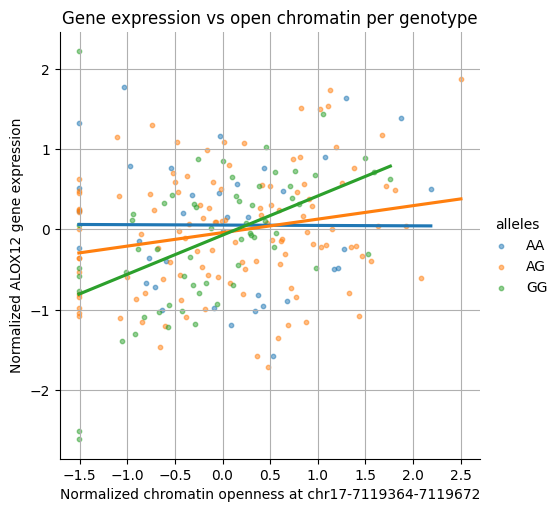

In [10]:
# plot the interaction
plt.figure(figsize=(10, 6))
sns.lmplot(data=interaction_table, x='omics2', y='omics1', hue='alleles', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin per genotype')
plt.xlabel('Normalized chromatin openness at chr17-7119364-7119672')
plt.ylabel('Normalized ALOX12 gene expression')
plt.grid(True)
plt.show()

<Figure size 1000x600 with 0 Axes>

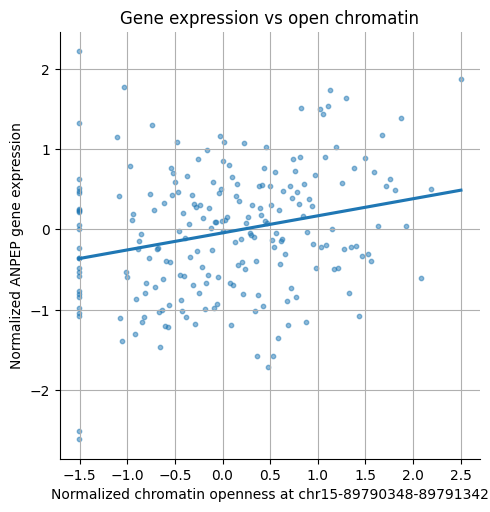

In [11]:
# plot the without the interaction
plt.figure(figsize=(10, 6))
sns.lmplot(data=interaction_table, x='omics2', y='omics1', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Gene expression vs open chromatin')
plt.xlabel('Normalized chromatin openness at chr15-89790348-89791342')
plt.ylabel('Normalized ANPEP gene expression')
plt.grid(True)
plt.show()

In [12]:
# get the eQTL table
eqtl_table = get_qtl_table(omics=rna_data, 
                 genotypes=genotypes, 
                 omics_smf=rna_smf, 
                 omics_feature='ALOX12', 
                 variant='17:7114639:A:G')
# add a binary genotype
eqtl_table['alleles'] = eqtl_table['genotype'].map({0.0 : 'AA', 1.0 : 'AG', 2.0 : 'GG'})
# and sort
eqtl_table = eqtl_table.sort_values('alleles')

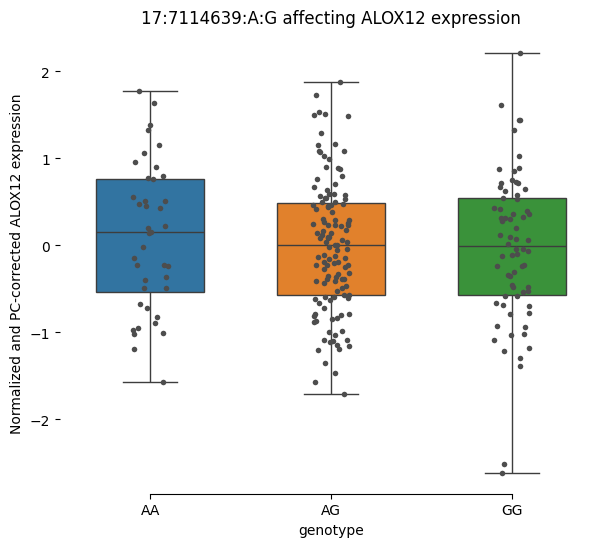

In [13]:
# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="alleles", y="omics", hue="alleles", data=eqtl_table, whis=[0, 100], width=.6).set(title = ' '.join(['17:7114639:A:G', 'affecting', 'ALOX12', 'expression']))
# Add in points to show each observation
sp = sns.stripplot(x="alleles", y="omics", data=eqtl_table, size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='Normalized and PC-corrected ALOX12 expression', xlabel='genotype')
sns.despine(trim=True, left=True)

In [14]:
# get the caQTL table
caqtl_table = get_qtl_table(omics=atac_data, 
                 genotypes=genotypes, 
                 omics_smf=atac_smf, 
                 omics_feature='chr17-7119364-7119672', 
                 variant='17:7114639:A:G')
# add a binary genotype
caqtl_table['alleles'] = eqtl_table['genotype'].map({0.0 : 'AA', 1.0 : 'AG', 2.0 : 'GG'})
# and sort
caqtl_table = caqtl_table.sort_values('alleles')

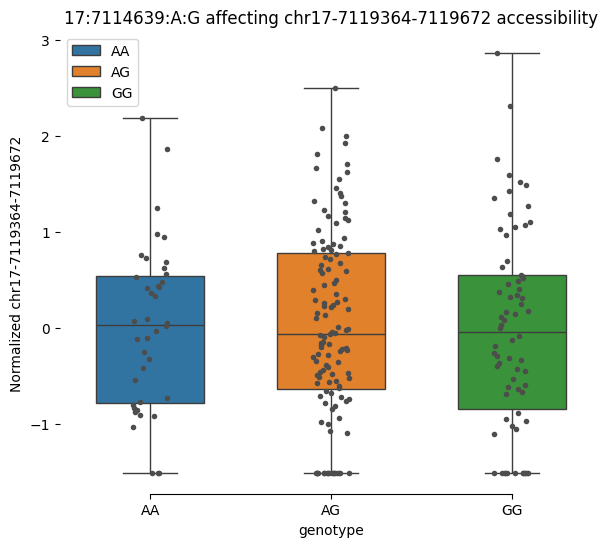

In [15]:
# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="alleles", y="omics", hue="alleles", data=caqtl_table, whis=[0, 100], width=.6).set(title = ' '.join(['17:7114639:A:G', 'affecting', 'chr17-7119364-7119672', 'accessibility']))
# Add in points to show each observation
sp = sns.stripplot(x="alleles", y="omics", data=caqtl_table, size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='Normalized chr17-7119364-7119672', xlabel='genotype')
sns.despine(trim=True, left=True)

In [16]:
# location of the expression and open chromatin co-accessibility/expression
coa_data_loc = '/groups/umcg-franke-scrna/tmp02/projects/multiome/ongoing/qtl/coaeqtl/sc-eqtlgen/input/L1/merged/monocyte.qtlInput.txt.gz'
# read the RNA data
coa_data = pd.read_csv(coa_data_loc, header = 0, sep = '\t', index_col = 0)

In [17]:
# get the caQTL table
coaqtl_table = get_qtl_table(omics=coa_data, 
                 genotypes=genotypes, 
                 omics_smf=atac_smf, 
                 omics_feature='chr17-7119364-7119672:ALOX12', 
                 variant='17:7114639:A:G')
# add a binary genotype
coaqtl_table['alleles'] = coaqtl_table['genotype'].map({0.0 : 'AA', 1.0 : 'AG', 2.0 : 'GG'})
# and sort
coaqtl_table = coaqtl_table.sort_values('alleles')

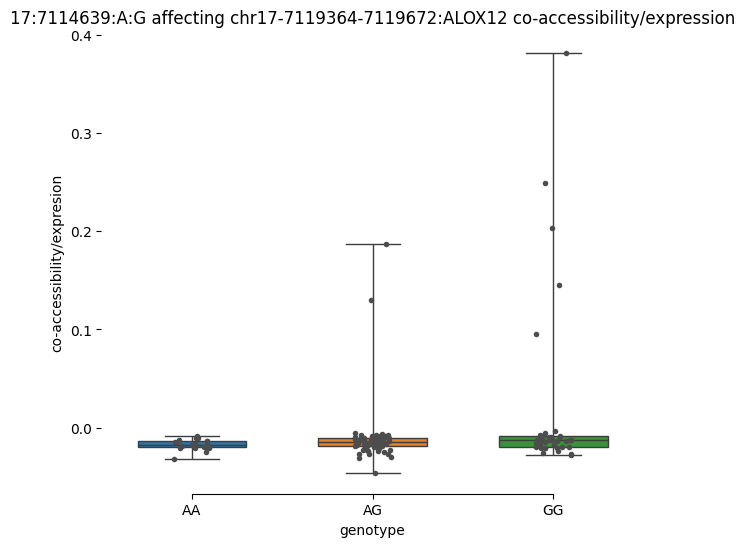

In [18]:
# set plots
f, ax = plt.subplots(figsize=(7, 6))            
# now create the plot
sb = sns.boxplot(x="alleles", y="omics", hue="alleles", data=coaqtl_table.dropna(), whis=[0, 100], width=.6).set(title = ' '.join(['17:7114639:A:G', 'affecting', 'chr17-7119364-7119672:ALOX12', 'co-accessibility/expression']))
# Add in points to show each observation
sp = sns.stripplot(x="alleles", y="omics", data=coaqtl_table.dropna(), size=4, color=".3", linewidth=0)
# Tweak the visual presentation
ax.xaxis.grid(False)
ax.set(ylabel='co-accessibility/expresion', xlabel='genotype')
sns.despine(trim=True, left=True)